# A Project for You



## Instructions

For this, you'll need to make several classification models and select the best one. Your notebook will illustrate and explain this process. 

### Detailed Requirements

<ol>
<li> You need one model per person. Decide on a slightly different approach for each person - you can change things like varaibles used, preparation, Regression or Bayes models, and othe things like that.</li>
<li> For each model, you must: </li>
    <ol>
    <li> Create a predictive model. </li>
    <li> Evaluate its performance. </li>
    <li> Create a markdown cell that explains your model choice and evaluation. </li>
    </ol>
<li> Overall, as a team, your team will select the best model from the selection. </li>
<li> <b> This needs to be in one workbook, containing: </b></li>
    <ol>
    <li> Initial data exploration/preparation from original data to 'ready for modeling'. Any preparation that is <b>common</b> to everyone should go here. Exact details will vary, but you want to explore the data visually as well as numerically. Focus on stuff that impacted decisions - what did you find in the data that caused you to take action or make a different choice? </li>
    <li> A markdown cell that briefly explains, ideally mostly in point form, what you found whilst exploring and what preparation you needed to do. Based on those findings, what are the different model approaches?</li>
    <li> Each person's model, evaluation, and explanation in their own section. </li>
    <li> An overall conclusion of what was best and how well it worked. Present your results in some kind of visualization. </li>
    </ol>
<li><b> In the workbook, please have the code that you settled on to explore, clean, model, and evaluate. In the explaination cells, give a brief explaination of what you did and how you got to what you settled on. </b> </li>
<li> In the data preparation, consider statistics stuff. Things such as transformations may be worth a try. </li>
<li> You don't need to spent an eternity tuning the models to get amazing results, we will worry more about that later. Make N reasonable choices on an approach to take based on what the data looks like, do the appropriate preparation, test the models, and observe the results. <b>The raw accuracy scores don't matter, only the approach.</b> </li>
</ol>

Overall, the workbook should clearly show what happened - you exlored the data, made some general processing steps, decided on different approaches based on what you found, created models according to each approach (model specific exploration/prep, model creation, evaluation), and an overall conclusion summarising what you found and what you would try next if you were to continue testing. In doing the data exploration especially, it is pretty normal to have several iterations of exploring and cleaning data - for example, you might add a filter for an outlier, look at a pair plot, adjust the filter, look at a pair plot, add another filter, look at a pair plot, and so on. Please don't show this literal process step by step, condense it down to what matters - something like, "here's the distributions, we did these outlier filters and removed these two features, here's the result", then continuing on. Basically, illustrate what happened and why, but not all of the back and forth or deliberation that went into it.

<b>Note:</b> I said that you can try Bayes as well; it isn't mandatory, but feel free. If you do, you'll need to likely do a little reading on the details of exactly what to use, there are a few variations on Bayes that aren't just 'Bayes' and you'll need to select. The documentation has a pretty good explainer (it is generally linkined in the 'user guide' link of each model's documentaion page, or google "sklearn naive bayes"), and things work more or less the same, you just need to meet the requirements of the specific model you choose.

### Submission and Marks
<ul>
<li> Check your work into the repository. I'm reading one file, so please make sure it is condensed. </li>
<li> Grade distribution: </li>
    <ul>
    <li> Your model - from the end of the common preparation to your evaluation and explaination. Was it done correctly. 25% </li>
    <li> Exploration and common preparation - code was clear, exploration was readable, preparation was done correctly, and explaination made sense. 25% </li>
    <li> Team choice on model approach - based on what you fond in exloration, you made reasonable choices on the different model approaches. 10% </li>
    <li> Overall conclusion - reasonable choice on best model, <b>thoughts on what you may try next if you were to keep testing</b>, and results presented clearly. 20% </li>
    <li> "Can I read and understand it?" - overall, you're explaining what you found, can I read it and understand what you did. 20% </li>
    </ul>
</ul>

#### Data Dictionary

📘 Overview

This dataset provides detailed information about students enrolled in various online courses. It includes demographic, behavioral, and performance features to predict whether a learner will complete the course or drop out.

📊 Key Details
<ul>
<li>Rows: 100,000</li>
<li>Target Variable: Completed</li>
</ul>

🧠 Feature Categories
<ul>
<li>Demographic: Gender, Age, Education_Level, Employment_Status</li>
<li>Course Info: Course_Level, Duration, Instructor_Rating</li>
<li>Engagement: Login_Frequency, Video_Completion_Rate, Discussion_Participation</li>
<li>Performance: Assignments_Submitted, Quiz_Score_Avg, Project_Grade, Progress_Percentage</li>
<li>Other: Payment_Mode, Discount_Used, App_Usage_Percentage</li>
</ul>

<b>Note:</b> The feature set is mixed, meaning there are both categorical and numerical variables present in the dataset. <b>Mixed featureds generally require different processing. We haven't done the tool that mixes these easily yet, that's fine and ok, we have stats instead. Right now, there are several decisions you can make to use both the numerical and categorical data together, think about how to represent the data and some of the options we have available for transformations.</b> This is part of what you want to figure out while exploring the data - you have a constraint on your ability to use mixed feature sets, yet you must use the data you <i>do</i> have, along with the different processing choices you can make, to create a model. Again, you are testing a few approaches against each other, the idea isn't to pick the best approach off the top of your head, it's to make reasonable attempts to narrow down what works best. This isn't a trick for one specific action, there's a bunch of things you can do that are reasonable. Later, we'll automate some of this, so we can try more things to work towards the 'best' model.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, root_mean_squared_error
import scipy.stats as ss
import thinkplot
import thinkstats2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
import pandas as pd

df = pd.read_csv("cleaned_student_data.csv")
TARGET_COL = "Completed"
print(df[TARGET_COL].describe())
df.sample(10)

count            100000
unique                2
top       Not Completed
freq              50970
Name: Completed, dtype: object


,Student_ID,Name,Gender,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,Course_Name,...,Assignments_Submitted,Quiz_Attempts,Progress_Percentage,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,App_Usage_Percentage,Satisfaction_Rating,Completed
57687,STU157687,Ananya Shah,Female,Bachelor,Employed,Chennai,Tablet,Low,C103,Introduction to AI,...,1,6,32.6,01-10-2024,NetBanking,Yes,No,64,4.0,Completed
57195,STU157195,Aditya Bose,Female,Bachelor,Unemployed,Lucknow,Laptop,Medium,C103,Introduction to AI,...,9,6,73.4,02-12-2024,Free,No,No,71,3.0,Not Completed
54010,STU154010,Rahul Iyer,Male,Diploma,Student,Hyderabad,Laptop,Medium,C103,Introduction to AI,...,8,3,73.2,19-12-2024,Credit Card,Yes,No,95,5.0,Completed
28244,STU128244,Neha Iyer,Female,Bachelor,Employed,Ahmedabad,Laptop,High,C105,UI/UX Design Fundamentals,...,2,4,27.8,04-01-2025,Credit Card,Yes,No,95,3.0,Completed
48929,STU148929,Pooja Sharma,Female,HighSchool,Employed,Kolkata,Mobile,High,C102,Data Analysis with Python,...,5,3,54.8,24-07-2025,Credit Card,Yes,Yes,82,3.0,Not Completed
5263,STU105263,Priya Bhardwaj,Male,Bachelor,Self-Employed,Bhopal,Laptop,High,C101,Python Basics,...,3,2,47.9,29-08-2024,Credit Card,Yes,No,14,4.0,Not Completed
85362,STU185362,Aditya Singh,Female,Master,Employed,Delhi,Laptop,High,C103,Introduction to AI,...,5,2,49.9,17-12-2023,Debit Card,Yes,Yes,33,4.0,Completed
55528,STU155528,Meera Desai,Male,Bachelor,Student,Delhi,Mobile,Low,C104,Digital Marketing Essentials,...,3,1,43.7,10-08-2024,UPI,Yes,No,57,5.0,Completed
5000,STU105000,Ananya Nair,Male,Master,Student,Pune,Laptop,Medium,C102,Data Analysis with Python,...,4,3,59.7,06-07-2024,Scholarship,No,No,72,4.0,Completed
28722,STU128722,Arjun Bose,Male,Diploma,Employed,Bhopal,Tablet,Medium,C102,Data Analysis with Python,...,4,6,39.9,25-05-2025,Debit Card,Yes,No,71,5.0,Not Completed


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Discussion_Participation,100000.0,2.329290,1.591365,0.0,1.0,2.0,3.0,12.0
Time_Spent_Hours,100000.0,3.873632,3.781185,0.5,0.5,2.7,6.2,25.6
Days_Since_Last_Login,100000.0,6.188860,6.982047,0.0,1.0,4.0,9.0,99.0
Peer_Interaction_Score,100000.0,6.294509,1.977552,0.0,4.9,6.3,7.7,10.0
Assignments_Submitted,100000.0,4.775430,1.664640,0.0,4.0,5.0,6.0,10.0
Quiz_Attempts,100000.0,3.772330,2.021276,0.0,2.0,4.0,5.0,16.0
Progress_Percentage,100000.0,53.823104,12.495622,7.6,45.4,53.9,62.4,98.6
App_Usage_Percentage,100000.0,67.859510,19.138354,0.0,55.0,68.0,82.0,100.0
Satisfaction_Rating,100000.0,4.135720,0.746730,1.0,4.0,4.0,5.0,5.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  object 
 1   Name                         100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Education_Level              100000 non-null  object 
 4   Employment_Status            100000 non-null  object 
 5   City                         100000 non-null  object 
 6   Device_Type                  100000 non-null  object 
 7   Internet_Connection_Quality  100000 non-null  object 
 8   Course_ID                    100000 non-null  object 
 9   Course_Name                  100000 non-null  object 
 10  Category                     100000 non-null  object 
 11  Course_Level                 100000 non-null  object 
 12  Discussion_Participation     100000 non-null  int64  
 13  

In [5]:
# Check for missing values

df.isnull().sum().sort_values()

Student_ID                     0
App_Usage_Percentage           0
Discount_Used                  0
Fee_Paid                       0
Payment_Mode                   0
Enrollment_Date                0
Progress_Percentage            0
Quiz_Attempts                  0
Assignments_Submitted          0
Peer_Interaction_Score         0
Days_Since_Last_Login          0
Time_Spent_Hours               0
Discussion_Participation       0
Course_Level                   0
Category                       0
Course_Name                    0
Course_ID                      0
Internet_Connection_Quality    0
Device_Type                    0
City                           0
Employment_Status              0
Education_Level                0
Gender                         0
Name                           0
Satisfaction_Rating            0
Completed                      0
dtype: int64

### Models:
- Multiple Logistic Regression - Marci
    - Y (target) = 'Completed'
- Decision Tree (Random Forest) - Shilvi
- Naive Bayes - Kevin



#### To Do:
- Explore data - COMPLETE
- Transformations - COMPLETE
- Filter outliers - COMPLETE
- Consider changing 'Fee_Paid', 'Discount_Used', and 'Completed' to boolean
- Reshape - COMPLETE
- Encode categorical columns
    - Nominal features - One-Hot encoding, drop last column
    - Ordinal features - Ordinal encoding
- Check multicollinearity (VIF)
- Remove features
- Remove categories if necessary


In [6]:
# Drop columns not relevant to predictions

df2 = df.drop(columns={'Student_ID', 'Name', 'Course_ID', 'Course_Name', 'Enrollment_Date', 'City'})

Dropped these columns because we believe they won't improve the predictive model and could potentially cause distrubances

In [7]:
# Should we keep 'Payment_Mode' and/or 'Fee_Paid'?

df2[df2['Fee_Paid']=='No']['Payment_Mode'].value_counts()

Payment_Mode
Free           19811
Scholarship    10039
Name: count, dtype: int64

In [8]:
count_pmt_free = df2['Payment_Mode'].value_counts()['Free']
count_pmt_sch = df2['Payment_Mode'].value_counts()['Scholarship']

count_fee_free = df2[df2['Fee_Paid']=='No']['Payment_Mode'].value_counts()['Free']
count_fee_sch = df2[df2['Fee_Paid']=='No']['Payment_Mode'].value_counts()['Scholarship']

dif_free = count_fee_free - count_pmt_free
dif_sch = count_fee_sch - count_pmt_sch

print('Difference - Free ', dif_free)
print('Difference - Scholarship ', dif_sch)

Difference - Free  0
Difference - Scholarship  0


In [9]:
df2 = df2.drop(columns={'Fee_Paid'})

Drop 'Fee_Paid' because 'Payment_Mode' gives us the same info but with more granularity.  Mainly interested in 'Scholarship' and 'Free'

In [10]:
# Visualize correlations (sample of 100)
# Might need to reconsider this... way too many variables

#sns.pairplot(df2.sample(100), hue='Completed', kind='reg')

In [11]:
# Create correlation matrix for numerical features

num_list = df2.select_dtypes(include='number').columns.tolist()                         # Get list of numerical columns

corr = df2[num_list].corr()
corr.style.background_gradient()

,Discussion_Participation,Time_Spent_Hours,Days_Since_Last_Login,Peer_Interaction_Score,Assignments_Submitted,Quiz_Attempts,Progress_Percentage,App_Usage_Percentage,Satisfaction_Rating
Discussion_Participation,1.000000,0.030708,-0.037039,0.056707,0.090871,0.076666,0.099584,0.032105,0.037540
Time_Spent_Hours,0.030708,1.000000,-0.014071,0.028299,0.030706,0.027819,0.034075,0.010859,0.013294
Days_Since_Last_Login,-0.037039,-0.014071,1.000000,-0.025742,-0.054597,-0.044541,-0.056965,-0.016807,-0.025186
Peer_Interaction_Score,0.056707,0.028299,-0.025742,1.000000,0.076765,0.056174,0.082565,0.032622,0.032156
Assignments_Submitted,0.090871,0.030706,-0.054597,0.076765,1.000000,0.098953,0.833256,0.048317,0.052991
Quiz_Attempts,0.076666,0.027819,-0.044541,0.056174,0.098953,1.000000,0.108285,0.038661,0.043303
Progress_Percentage,0.099584,0.034075,-0.056965,0.082565,0.833256,0.108285,1.000000,0.051809,0.056563
App_Usage_Percentage,0.032105,0.010859,-0.016807,0.032622,0.048317,0.038661,0.051809,1.000000,0.020783
Satisfaction_Rating,0.037540,0.013294,-0.025186,0.032156,0.052991,0.043303,0.056563,0.020783,1.000000


In [12]:
# Drop numerical features with visually obvious correlation

df2 = df2.drop(columns={'Assignments_Submitted'})

Dropped 'Assignments_Submitted' column because of the high correlation with Progress_Percentage (multicollinearity).  

In [13]:
# Prep work for loops and stuff

num_list = df2.select_dtypes(include='number').columns.tolist()                         # Get list of numerical columns
cat_list = df2.select_dtypes(include=['object', 'category']).columns.tolist()           # Get list of categorical columns

In [14]:
# Convert dtype object columns to dtype category

for column in cat_list:
    df2[column] = df2[column].astype('category')

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   Gender                       100000 non-null  category
 1   Education_Level              100000 non-null  category
 2   Employment_Status            100000 non-null  category
 3   Device_Type                  100000 non-null  category
 4   Internet_Connection_Quality  100000 non-null  category
 5   Category                     100000 non-null  category
 6   Course_Level                 100000 non-null  category
 7   Discussion_Participation     100000 non-null  int64   
 8   Time_Spent_Hours             100000 non-null  float64 
 9   Days_Since_Last_Login        100000 non-null  int64   
 10  Peer_Interaction_Score       100000 non-null  float64 
 11  Quiz_Attempts                100000 non-null  int64   
 12  Progress_Percentage          100000 non-null 

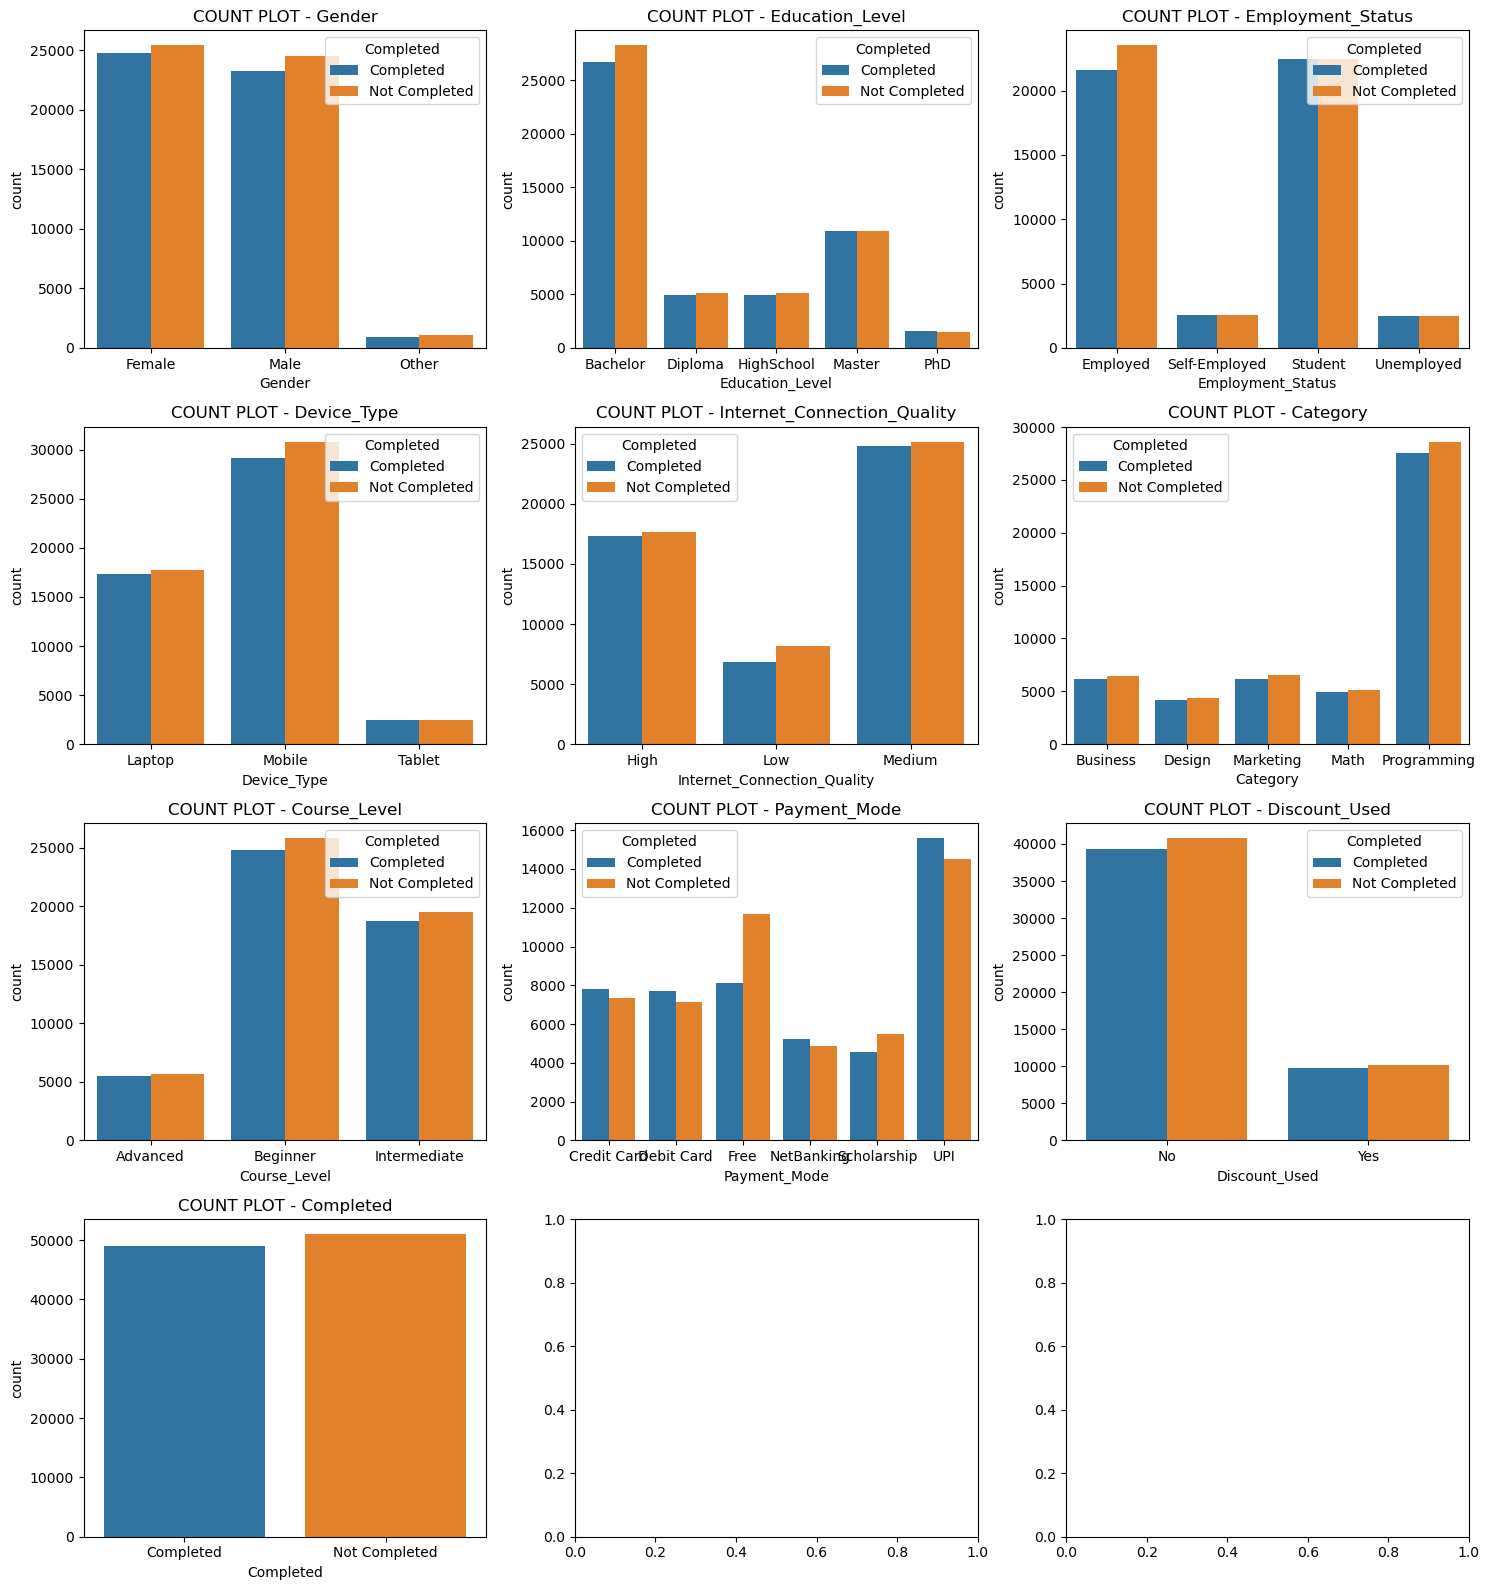

In [15]:
# Explore data distribution, check for outliers - CATEGORICAL FEATURES

sub_rows = len(cat_list) // 3 + 1                                           # Use length of columns as number of subplot rows
sub_cols = 3                                                                # Number of subplot columns

fig, ax = plt.subplots(sub_rows, sub_cols, figsize=(15,4*sub_rows))         # Create subplots based on number of columns in list
ax = ax.flatten()

for i, column in enumerate(cat_list):                                       # Loop through df (need index for plotting)

    sns.countplot(df2, x=column, ax=ax[i], hue='Completed')                 # Create count plots
    ax[i].set_title(f'COUNT PLOT - {column}')
    plt.tight_layout()

plt.show()

No categorical features that need to be filtered at this point

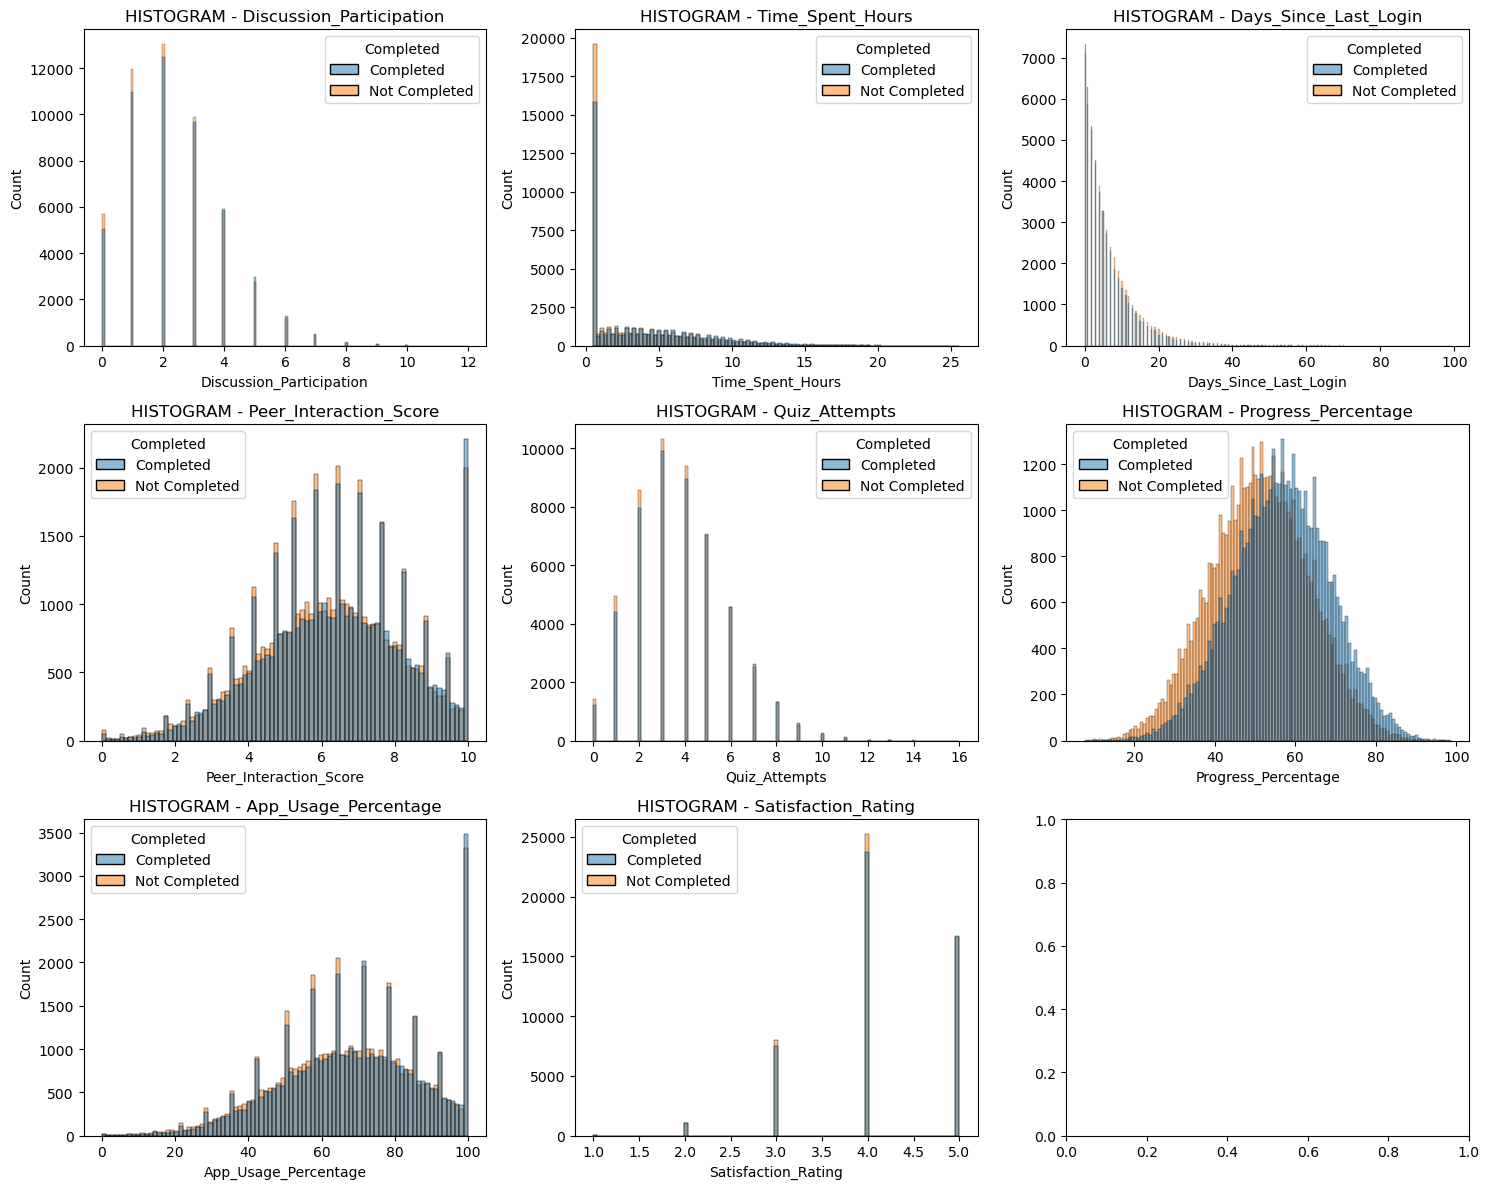

In [16]:
# Explore data distribution, check for outliers - NUMERICAL FEATURES

sub_rows = (len(num_list)+1) // 3                                                               # Use length of columns as number of subplot rows
sub_cols = 3                                                                                    # Number of subplot columns

fig, ax = plt.subplots(sub_rows, sub_cols, figsize=(15,4*sub_rows))                             # Create subplots based on number of columns in list
ax = ax.flatten()

for i, column in enumerate(num_list):                                                            # Loop through df (need index for plotting)

    sns.histplot(df2, x=column, ax=ax[i], hue='Completed', alpha=0.5)
    ax[i].set_title(f'HISTOGRAM - {column}')
    plt.tight_layout()

plt.show()

- A couple of obvious outliers that should be removed
- A few weird patterns happening in some of the features ('Time_Spent_Hours', 'Peer_Interaction_Score', 'App_Usage_Percentage')
- 'Days_Since_Last_Login' and 'Time_Spent_Hours' will need log transformation

In [17]:
# Filter obvious outliers

#df2['Time_Spent_Hours'].value_counts()                 # Checked each features value count

df2 = df2[df2['App_Usage_Percentage'] != 100]           # Filter out values with extremely high value counts
df2 = df2[df2['Peer_Interaction_Score'] != 10]
df2 = df2[df2['Time_Spent_Hours'] != 0.5]

In [18]:
# Log transform data

df2["Days_Since_Last_Login_log"] = np.log1p(df2['Days_Since_Last_Login'])   # Use np.log1p instead of no.lop because there are zero values
df2["Time_Spent_Hours_log"] = np.log1p(df2['Time_Spent_Hours'])

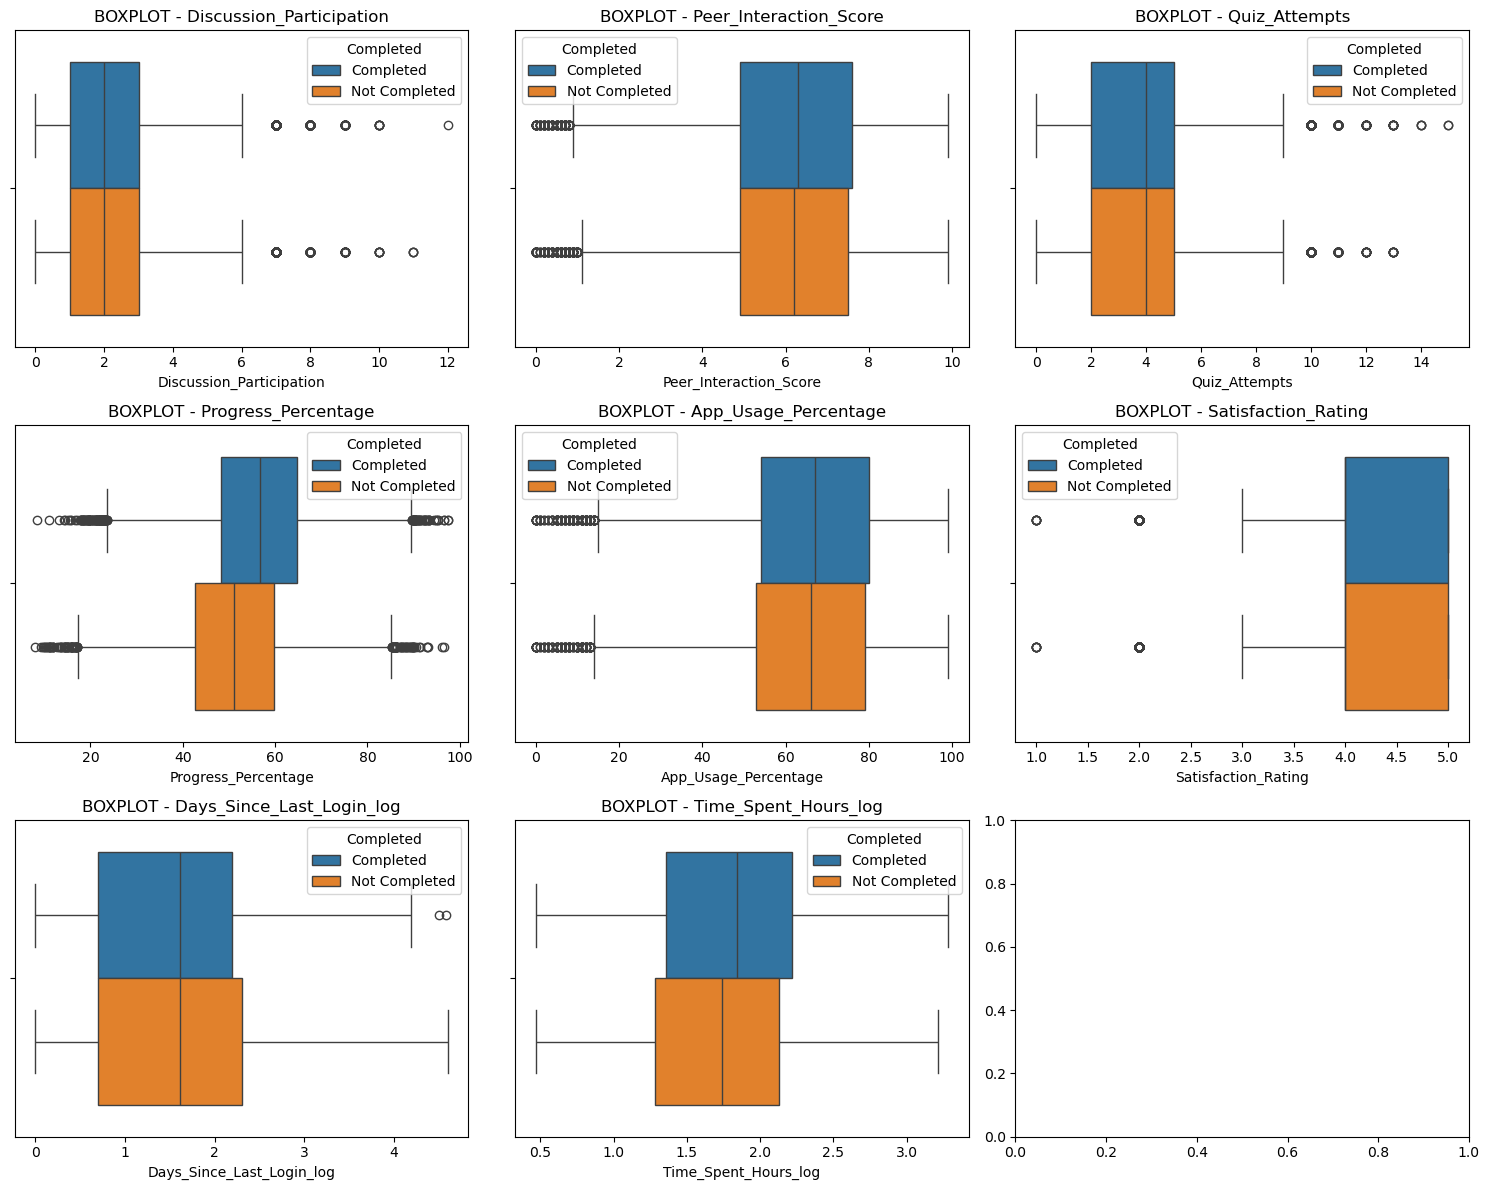

In [19]:
# Explore data distribution, check for outliers - NUMERICAL FEATURES - Box Plots

num_list = df2.drop(columns={'Days_Since_Last_Login', 'Time_Spent_Hours'}).select_dtypes(include='number').columns.tolist()     # Update num_list with log transformed data
sub_rows = (len(num_list)+1) // 3                                                               # Use length of columns as number of subplot rows
sub_cols = 3                                                                                    # Number of subplot columns

fig, ax = plt.subplots(sub_rows, sub_cols, figsize=(15,4*sub_rows))                             # Create subplots based on number of columns in list
ax = ax.flatten()

for i, column in enumerate(num_list):                                                           # Loop through df (need index for plotting)

    sns.boxplot(df2, x=column, ax=ax[i], hue='Completed')                                       # Create boxplot
    ax[i].set_title(f'BOXPLOT - {column}')                                
    ax[i].set_xlabel(column)   
    plt.tight_layout()

plt.show()

In [20]:
# Filter outliers

df2 = df2[df2['Discussion_Participation'] < 7]          
df2 = df2[df2['Peer_Interaction_Score'] > 1]
df2 = df2[df2['Quiz_Attempts'] < 10]
df2 = df2[(df2['Progress_Percentage'] > 20) & (df2['Progress_Percentage'] < 90)]
df2 = df2[df2['App_Usage_Percentage'] > 17]
df2 = df2[df2['Satisfaction_Rating'] > 2]

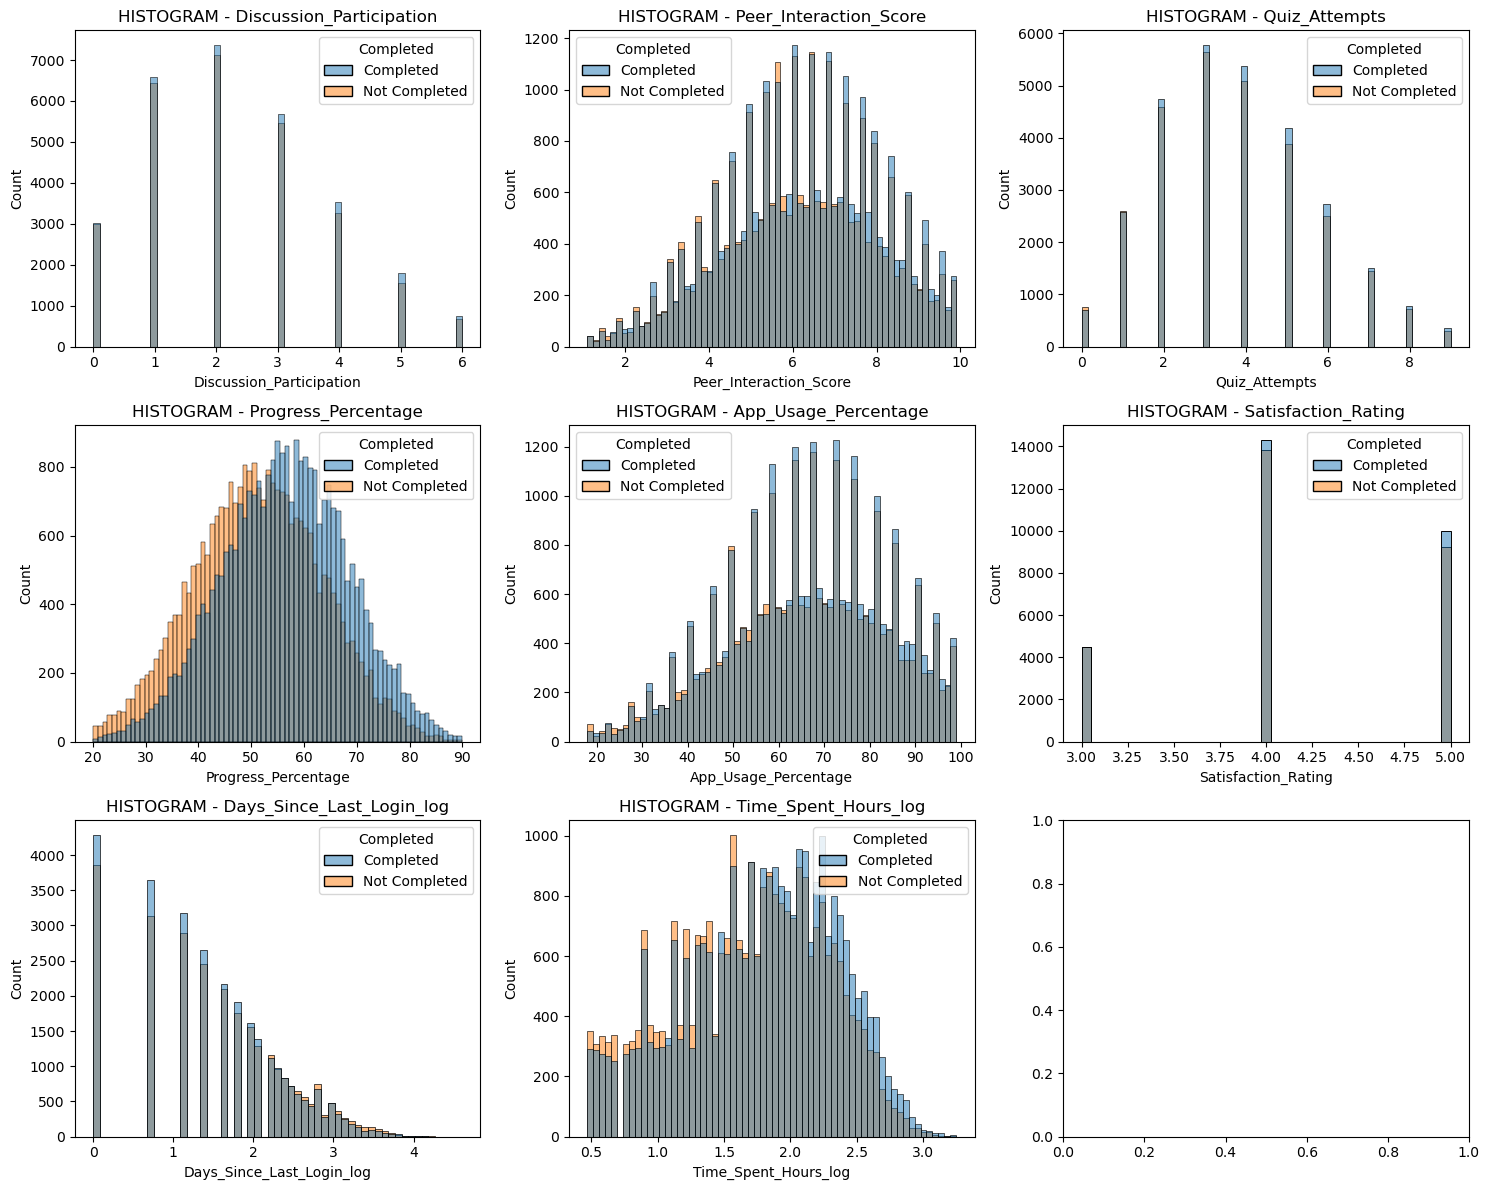

In [21]:
# Recheck data distribution

sub_rows = (len(num_list)+1) // 3                                                               # Use length of columns as number of subplot rows
sub_cols = 3                                                                                    # Number of subplot columns

fig, ax = plt.subplots(sub_rows, sub_cols, figsize=(15,4*sub_rows))                             # Create subplots based on number of columns in list
ax = ax.flatten()

for i, column in enumerate(num_list):                                                            # Loop through df (need index for plotting)

    sns.histplot(df2, x=column, ax=ax[i], hue='Completed', alpha=0.5)
    ax[i].set_title(f'HISTOGRAM - {column}')
    plt.tight_layout()

plt.show()

In [22]:
# Split data into features (Xs) and target (Y)

dfY = df2['Completed']                                                                  # Target
dfX = df2.drop(columns={'Completed', 'Days_Since_Last_Login', 'Time_Spent_Hours'})      # Features - drop log-normal data, keep log-transformed

In [23]:
# Convert target to float

dfY = dfY.map({'Completed': True, 'Not Completed': False}).astype(float)

In [24]:
# Encode nominal features

nominal_cols = ['Gender', 'Employment_Status', 'Device_Type', 'Category', 'Payment_Mode', 'Discount_Used']
dfX = pd.get_dummies(dfX, columns=nominal_cols, drop_first=True)

# Encode ordinal features

ordinal_cols = ['Education_Level', 'Internet_Connection_Quality', 'Course_Level']
ordinal_order = [['HighSchool', 'Diploma', 'Bachelor', 'Master', 'PhD'],
                 ['Low', 'Medium', 'High'],
                 ['Beginner', 'Intermediate', 'Advanced']]

from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder(categories=ordinal_order)
dfX[ordinal_cols] = ord_enc.fit_transform(dfX[ordinal_cols])

dfX.sample(5)

,Education_Level,Internet_Connection_Quality,Course_Level,Discussion_Participation,Peer_Interaction_Score,Quiz_Attempts,Progress_Percentage,App_Usage_Percentage,Satisfaction_Rating,Days_Since_Last_Login_log,...,Category_Design,Category_Marketing,Category_Math,Category_Programming,Payment_Mode_Debit Card,Payment_Mode_Free,Payment_Mode_NetBanking,Payment_Mode_Scholarship,Payment_Mode_UPI,Discount_Used_Yes
44411,2.0,1.0,0.0,2,5.7,4,50.2,95,4.0,0.693147,...,False,False,False,False,True,False,False,False,False,True
81507,1.0,1.0,1.0,2,2.4,6,66.6,91,3.0,2.079442,...,False,False,True,False,False,False,False,False,False,False
81266,3.0,1.0,0.0,5,5.6,3,44.9,71,4.0,2.079442,...,False,False,False,False,False,False,False,False,True,False
3544,2.0,0.0,1.0,0,7.1,2,42.0,57,5.0,0.693147,...,False,False,False,True,True,False,False,False,False,False
97350,2.0,1.0,1.0,2,6.1,8,37.1,72,4.0,1.945910,...,False,False,False,True,False,True,False,False,False,False


In [25]:
# Convert features to float

dfX = dfX.astype(float)

In [26]:
# Reshape data

y = np.array(dfY).reshape(-1,1)
x = np.array(dfX)
x.shape, y.shape

((56243, 28), (56243, 1))

In [27]:
# Calc Variance Inflaction Factors

def calc_vif(X):
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return(vif)

calc_vif(dfX)

,variables,VIF
0,Education_Level,5.403177
1,Internet_Connection_Quality,4.143426
2,Course_Level,3.026724
3,Discussion_Participation,3.394496
4,Peer_Interaction_Score,11.790340
5,Quiz_Attempts,4.786583
6,Progress_Percentage,18.799036
7,App_Usage_Percentage,13.970445
8,Satisfaction_Rating,27.254803
9,Days_Since_Last_Login_log,3.574153


In [28]:
# Create correlation matrix for 'Satisfaction_Rating'/'Progress_Percentage'/'App_Usage_Percentage'/'Peer_Interaction_Score' features

corrs = dfX.corr()['Peer_Interaction_Score'].sort_values(ascending=False)
corrs

Peer_Interaction_Score             1.000000
Progress_Percentage                0.074140
Quiz_Attempts                      0.044495
Discussion_Participation           0.044042
Employment_Status_Student          0.037870
Internet_Connection_Quality        0.037557
Satisfaction_Rating                0.027177
App_Usage_Percentage               0.022455
Time_Spent_Hours_log               0.021169
Employment_Status_Self-Employed    0.012316
Education_Level                    0.010275
Device_Type_Tablet                 0.007054
Employment_Status_Unemployed       0.006328
Gender_Male                        0.005660
Category_Marketing                 0.004416
Category_Math                      0.003726
Category_Design                    0.002370
Payment_Mode_NetBanking            0.000585
Payment_Mode_Scholarship          -0.000104
Payment_Mode_Free                 -0.000301
Payment_Mode_UPI                  -0.001815
Course_Level                      -0.002057
Discount_Used_Yes               

Don't see anything that we want to remove. Moving on.

### Marci's Model

In [29]:
# Import libraries

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [30]:
dfX.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56243 entries, 1 to 99999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Education_Level                  56243 non-null  float64
 1   Internet_Connection_Quality      56243 non-null  float64
 2   Course_Level                     56243 non-null  float64
 3   Discussion_Participation         56243 non-null  float64
 4   Peer_Interaction_Score           56243 non-null  float64
 5   Quiz_Attempts                    56243 non-null  float64
 6   Progress_Percentage              56243 non-null  float64
 7   App_Usage_Percentage             56243 non-null  float64
 8   Satisfaction_Rating              56243 non-null  float64
 9   Days_Since_Last_Login_log        56243 non-null  float64
 10  Time_Spent_Hours_log             56243 non-null  float64
 11  Gender_Male                      56243 non-null  float64
 12  Gender_Other           

In [31]:
# Split data into Train and Test

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33)
print("X-Train:", X_train.shape)
print("X-Test:", X_test.shape)
print("Y-Train:", y_train.shape)
print("Y-Test:", y_test.shape)

X-Train: (37682, 28)
X-Test: (18561, 28)
Y-Train: (37682, 1)
Y-Test: (18561, 1)


In [32]:
# Fit model

model = LogisticRegression(max_iter=1000).fit(X_train,y_train.ravel())

# Make prediction

model_pred = model.predict(X_test)

# Calc accuracy

score = model.score(X_test, y_test)
print('Accuracy Score: ', round(score*100, 1), '%')

Accuracy Score:  59.6 %


<Axes: >

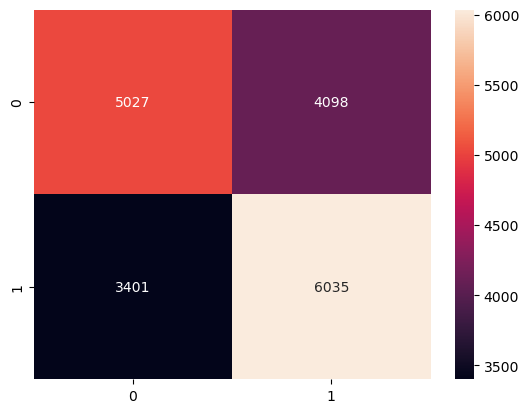

In [33]:
# Figure out how many predictions fall in each category 
    # True Neg, False Pos
    # False Neg, True Pos

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix 
conf_matrix = confusion_matrix(y_test, model_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d')

In [34]:
# Classification report

print(classification_report(y_test, model_pred, digits=2))

              precision    recall  f1-score   support

         0.0       0.60      0.55      0.57      9125
         1.0       0.60      0.64      0.62      9436

    accuracy                           0.60     18561
   macro avg       0.60      0.60      0.59     18561
weighted avg       0.60      0.60      0.60     18561



***Model is correct 60% of the time, so not great***

### Person 2: Random Forest Classification Model by Shilvi Patel

#### Model Selection:
<li>A Random Forest classifier was selected for this modeling approach to capture non-linear relationships and interactions among features that simpler linear or probailistic models may miss.</li>
<li>The dataset contains a large number of categorical variables as well as continuous engagement metrics. Random Forest is well-suited to this structure because it can handle complex decision boundaries and feature interactions without strong assumptions about the underlying data distribution.</li>
<li>This model provides a contrast to linear and probabilistic approaches used by other team members.</li>

#### Preparation for Random Forest
The Random Forest model uses the commom preprocessing pipeline definesd earlier in the notebook:
<li>Numeric features were scaled uing StandarScaler (for consistency across models.)</li>
<li>Categorical features were one-hot encoded.</li>
<li>A stratified train-test split was used to preserve the class distribution of the target variable.</li>
No additional feature selection or transformations were applied, as Random Forest is robust to irrelevant features and does not reuire strict normalization.

#### Feature Set for Random Forest includes:
<li>Engagement metrics: progress, app usage, satisfaction, quiz attempts, interactions</li>
<li>Access/context: device type, internet quality, employment/education</li>
<li>Course/payment context: course level, category, payment mode, discount usage</li>
<li>Log-transformed time-based engagement variables</li>

In [35]:
# features
person2_features = [
    # engagement / behavior
    "Progress_Percentage",
    "App_Usage_Percentage",
    "Satisfaction_Rating",
    "Discussion_Participation",
    "Peer_Interaction_Score",
    "Quiz_Attempts",
    "Days_Since_Last_Login_log",
    "Time_Spent_Hours_log",

    # student context
    "Gender",
    "Education_Level",
    "Employment_Status",
    "Device_Type",
    "Internet_Connection_Quality",

    # course + payment context
    "Course_Level",
    "Category",
    "Payment_Mode",
    "Discount_Used"
]

df2_p2 = df2[person2_features + [TARGET_COL]].copy()         # creating modeling for dataset for person 2


In [37]:
# using already-encoded features from common preparation

X_p2 = dfX.copy()
y_p2 = dfY.copy()


#### Train–Test Split (Evaluation Setup)
To evaluate performance fairly, I split the data into:
<li>80% training (used to fit the Random Forest model)</li>
<li>20% testing (used only for evaluation)</li>
I used stratification to keep the proportion of Completed vs Not Completed consistent across both sets.
I also fixed random_state=42 to ensure reproducibility.

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_p2, y_p2,
    test_size=0.2,
    random_state=42,
    stratify=y_p2
)


#### Q.Why Random Forest?
Random Forest was chosen because:
<li>It handles non-linear relationships well</li>
<li>It captures feature interactions automatically</li>
<li>It performs strongly with mixed feature types after encoding</li>
<li>It is robust to noise and does not require heavy tuning for a first model comparison</li>
<li>This makes it appropriate for predicting course completion based on student behavior patterns.</li>

#### Model Evaluation
To evaluate the Random Forest model, I used:
<li>Accuracy</li>
<li>F1-score (weighted) to balance performance across both classes</li>
<li>Classification report (precision, recall, F1 per class)</li>
<li>Confusion matrix to see where misclassifications occur</li>
These metrics provide a clearer evaluation than accuracy alone.


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (weighted):", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.5837852253533647
F1 (weighted): 0.5831215126960997

Classification Report:
               precision    recall  f1-score   support

         0.0       0.58      0.54      0.56      5504
         1.0       0.59      0.62      0.60      5745

    accuracy                           0.58     11249
   macro avg       0.58      0.58      0.58     11249
weighted avg       0.58      0.58      0.58     11249


Confusion Matrix:
 [[2991 2513]
 [2169 3576]]


#### Interpretation of Results
<li>The Random Forest model provides a strong predictive baseline for course completion.</li>
<li>If the model shows strong recall for the “Not Completed” class, it means the model can identify students at risk of dropping out, which would be valuable for early intervention.</li>
<li>Misclassifications may occur when students have similar engagement patterns but different completion outcomes.</li>
<li>This suggests that additional features (such as assignment deadlines, instructor activity, or weekly engagement changes) could further improve prediction quality.</li>

### Kevin's Model

Model Selection: Naive Bayes
- Chosen as a simple probabilistic baseline to compare against more complex models.

- Works well with large datasets (100k rows) and trains extremely fast.

- Provides a clear, explainable approach using conditional probabilities.

- Suitable under the assumption that features are conditionally independent given course completion.

- Ideal for testing whether basic statistical structure in the data is sufficient for prediction.

Target distribution:
Completed
1    49030
Name: count, dtype: int64 

Accuracy: 1.0000
Weighted F1: 1.0000

Classification report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      9806

    accuracy                           1.00      9806
   macro avg       1.00      1.00      1.00      9806
weighted avg       1.00      1.00      1.00      9806



c:\Users\msieb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


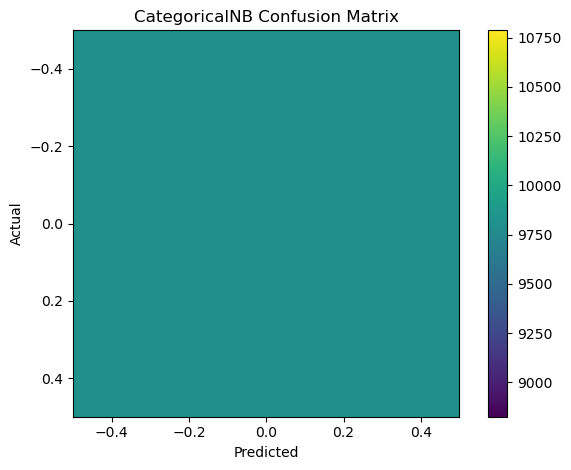

In [40]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_student_data.csv")
TARGET = "Completed"

if df[TARGET].dtype == "object":
    s = df[TARGET].astype(str).str.strip().str.lower()

    mapping = {
        "1": 1, "true": 1, "yes": 1, "y": 1, "completed": 1, "complete": 1,
        "0": 0, "false": 0, "no": 0, "n": 0, "dropout": 0, "dropped out": 0, "dropped": 0
    }
    df[TARGET] = s.map(mapping)
else:

    df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

df[TARGET] = df[TARGET].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=[TARGET])

df[TARGET] = df[TARGET].astype(int)

print("Target distribution:")
print(df[TARGET].value_counts(), "\n")

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

def fit_bins_and_encode(train_df, test_df, num_cols, cat_cols, n_bins=5):
    train_enc = pd.DataFrame(index=train_df.index)
    test_enc  = pd.DataFrame(index=test_df.index)

    # Categorical columns
    for c in cat_cols:
        tr = train_df[c].astype("object").fillna("Missing")
        te = test_df[c].astype("object").fillna("Missing")

        cats = pd.Index(tr.unique())
        tr_codes = cats.get_indexer(tr)
        te_codes = cats.get_indexer(te)  # unseen -> -1

        # shift by +1 so everything is >= 0
        train_enc[c] = (tr_codes + 1).astype(int)
        test_enc[c]  = (te_codes + 1).astype(int)

    # Numeric columns -> quantile bins
    for c in num_cols:
        tr = pd.to_numeric(train_df[c], errors="coerce")
        te = pd.to_numeric(test_df[c], errors="coerce")

        med = tr.median()
        tr = tr.fillna(med)
        te = te.fillna(med)

        # bins from train
        binned_tr, edges = pd.qcut(tr, q=n_bins, retbins=True, duplicates="drop")
        binned_te = pd.cut(te, bins=edges, include_lowest=True)

        train_enc[c] = (binned_tr.cat.codes + 1).astype(int)
        test_enc[c]  = (binned_te.cat.codes + 1).astype(int)  # outside range -> 0
        test_enc[c]  = test_enc[c].clip(lower=1)              # keep >= 1

    return train_enc, test_enc

Xtr_enc, Xte_enc = fit_bins_and_encode(X_train, X_test, num_cols, cat_cols, n_bins=5)

# ----------------------------
# 5) Model: Categorical Naive Bayes
# ----------------------------
nb = CategoricalNB(alpha=1.0)
nb.fit(Xtr_enc, y_train)

y_pred = nb.predict(Xte_enc)

# ----------------------------
# 6) Evaluation
# ----------------------------
acc = accuracy_score(y_test, y_pred)
f1w = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy: {acc:.4f}")
print(f"Weighted F1: {f1w:.4f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("CategoricalNB Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()


Preparation for Naive Bayes

- Dataset contains mixed feature types, but Naive Bayes requires a consistent input format.

- Numeric features were transformed into quantile-based bins (e.g., very low → very high) to reduce skew and outlier effects.

- Categorical features were cleaned, missing values filled with "Missing", and encoded as integer categories.

- Target variable (Completed) was normalized and safely mapped to 0/1, removing invalid or missing labels.

- All features were converted to non-negative integer values, satisfying Categorical Naive Bayes requirements.

Feature Set for Naive Bayes includes

- Demographic: Gender, Age (binned), Education_Level, Employment_Status

- Course Info: Course_Level, Duration (binned), Instructor_Rating (binned)

- Engagement: Login_Frequency (binned), Video_Completion_Rate (binned), Discussion_Participation (binned), App_Usage_Percentage (binned)

- Performance: Assignments_Submitted (binned), Quiz_Score_Avg (binned), Project_Grade (binned), Progress_Percentage (binned)

Other: Payment_Mode, Discount_Used

Evaluation Approach

- Accuracy used as a general baseline metric.

- Weighted F1-score used to account for potential class imbalance (completion vs dropout).

- Confusion matrix used to identify which class (Completed or Dropout) is more frequently misclassified.

Reason for choosing Naive Bayes

- Naive Bayes provides a strong baseline with minimal tuning.

- The model highlights whether simple statistical patterns in engagement and performance are enough to predict completion.

- esults from this model are used as a comparison point for more flexible models (e.g., Random Forest)

Outputinterpretation

The Naive Bayes model achieved moderate performance, showing that the dataset contains meaningful statistical patterns related to course completion.

Accuracy and weighted F1-score indicate the model works well as a baseline, but performance is stronger for the majority class.

The confusion matrix shows that completed courses are predicted more accurately than dropouts.

Misclassifications are common for learners with mixed engagement and performance signals.

The model’s conditional independence assumption limits its ability to capture interactions between features.